In [19]:
import os
import sys

# Standard interactive replacement for the 'parent directory' hack
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)

import pandas as pd
import numpy as np
from tqdm.notebook import tqdm

from PPRCalculator import PPRCalculator
from ModelData import ModelData

# EwE reproduce

In [2]:
DC_b = 0.5/100.5
DC_pp = 100/100.5

TE_a = 10/100.5

DC_pp/TE_a
1/TE_a

10.049999999999999

In [3]:
GE_14 = 0.3059360730593607
GE_16 = 0.29213483146067415
GE_17 = 1.0
GE_19 = 1.0

EE_14 = 0.48304227
EE_16 = 0.7744968
EE_17 = 0.2676308
EE_19 = 1

TE = pd.Series({
    14: GE_14*EE_14,
    16: GE_16*EE_16,
    17: GE_17*EE_17,
    19: GE_19*EE_19,
}).T.to_frame()

EE = pd.Series({
    14: EE_14,
    16: EE_16,
    17: EE_17,
    19: EE_19,
}).T.to_frame()

DC = pd.DataFrame({
    19: [0, 0, 0, 0],
    17: [0, 0, 0, 0],
    16: [0.3, 0.5, 0, 0.2],
    14: [0.9, 0, 0.05, 0.05]
}, index=[19, 17, 16, 14]).T

A = DC.div(TE[0], axis=0)

In [4]:
# SPPR_16
(0.5/(GE_16) + 0.3/(GE_16) + 0.2/(GE_16) * 0.9/(GE_14*EE_14))

6.907859400014105

In [5]:
(0.5/(GE_16*EE_16) + 0.3/(GE_16*EE_16) + 0.2/(GE_16*EE_16) * 0.9/(GE_14*EE_14)) * EE_16

6.907859400014106

In [6]:
# SPPR_14
0.9/(GE_14) + (0.05/(GE_14))*(0.3/(GE_16*EE_16) + 0.5/(GE_16*EE_16))

3.519655969482357

In [7]:
(0.9/(GE_14*EE_14) + (0.05/(GE_14*EE_14))*((0.3/(GE_16*EE_16)) + 0.5/(GE_16*EE_16))) * EE_14

3.519655969482357

In [8]:
3.519656

3.519656

# Other tests

In [9]:
# model_number = 496
# model_number = 240
# model_number = 473
# model_number = 240
model_number = 7
model_number = 105
self = PPRCalculator(model_number)
tls = self.get_TL(break_cycles=False, DET_as_PP=True)
tls
# self.get_groups_df()
# self.GS

51    1.000000
50    1.000000
49    1.000000
48    2.000000
47    2.557895
46    2.000000
45    2.000000
44    2.000000
43    2.000000
42    2.456947
41    2.931141
40    3.084426
39    2.918381
38    3.278947
37    3.962739
36    3.383981
35    3.418421
34    4.079139
33    3.286200
32    3.383691
31    3.195263
30    3.257178
29    4.262008
28    4.039071
27    3.589091
26    3.107302
25    3.280185
24    3.355285
23    3.908335
22    4.284176
21    3.849741
20    3.682842
19    4.000049
18    4.215009
17    3.080570
16    3.021204
15    3.121576
14    4.224592
13    4.382093
12    3.365384
11    3.446879
10    3.621015
9     3.953452
8     3.533849
7     4.280328
6     3.000000
5     4.422608
4     4.125564
3     4.402161
2     4.100458
1     3.313252
dtype: float64

# GS distribution

In [10]:
path = 'real_models/data/'
saved_models = [int(f.split('[')[1].split(']')[0]) for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))]

In [11]:
gs_list = []
tl_list = []
tl_groups_list = []
trophic_info_list = []
models_list = []
names_list = []

for model_number in tqdm(saved_models):
    # create model calculator:
    try:
        model = PPRCalculator(model_number)
        groups_df = model.get_groups_df()
        groups_df['tl'] = model.get_TL(break_cycles=False, DET_as_PP=True)
        groups_df['gs'] = model.GS.fillna(0)
        groups_df['tl_groups'] = groups_df['tl'].copy()
        groups_df = groups_df[['group_name', 'trophic_info', 'tl', 'tl_groups', 'gs']]
        groups_df.loc[~groups_df['tl_groups'].isin([1, 2]), 'tl_groups'] = 0
        tl_list += groups_df['tl'].tolist()
        tl_groups_list += groups_df['tl_groups'].tolist()
        gs_list += groups_df['gs'].tolist()
        trophic_info_list += groups_df['trophic_info'].tolist()
        names_list += groups_df['group_name'].tolist()
        models_list += [model_number] * len(groups_df)
    except:
        print(model_number)
        continue

100%|██████████| 119/119 [00:09<00:00, 12.78it/s]


In [12]:
df = pd.DataFrame(data={
    'model_number': models_list,
    'trophic_info': trophic_info_list,
    'group_name': names_list,
    'tl': tl_list,
    'tl_groups': tl_groups_list,
    'gs': gs_list,
})
df

,model_number,trophic_info,group_name,tl,tl_groups,gs
0,105,Import,diet_import,1.000000,1.0,0.0
1,105,DET,Detritus,1.000000,1.0,0.0
2,105,PP,Phytoplankton,1.000000,1.0,0.0
3,105,Regular,S.Zooplankton,2.000000,2.0,0.2
4,105,Regular,L.Zooplankton,2.557895,0.0,0.2
...,...,...,...,...,...,...
3461,7,Regular,Loligo,3.958886,0.0,0.2
3462,7,Regular,large zoopl,2.765306,0.0,0.4
3463,7,Regular,small zoopl,2.000000,2.0,0.4
3464,7,PP,macrophytes,1.000000,1.0,0.0


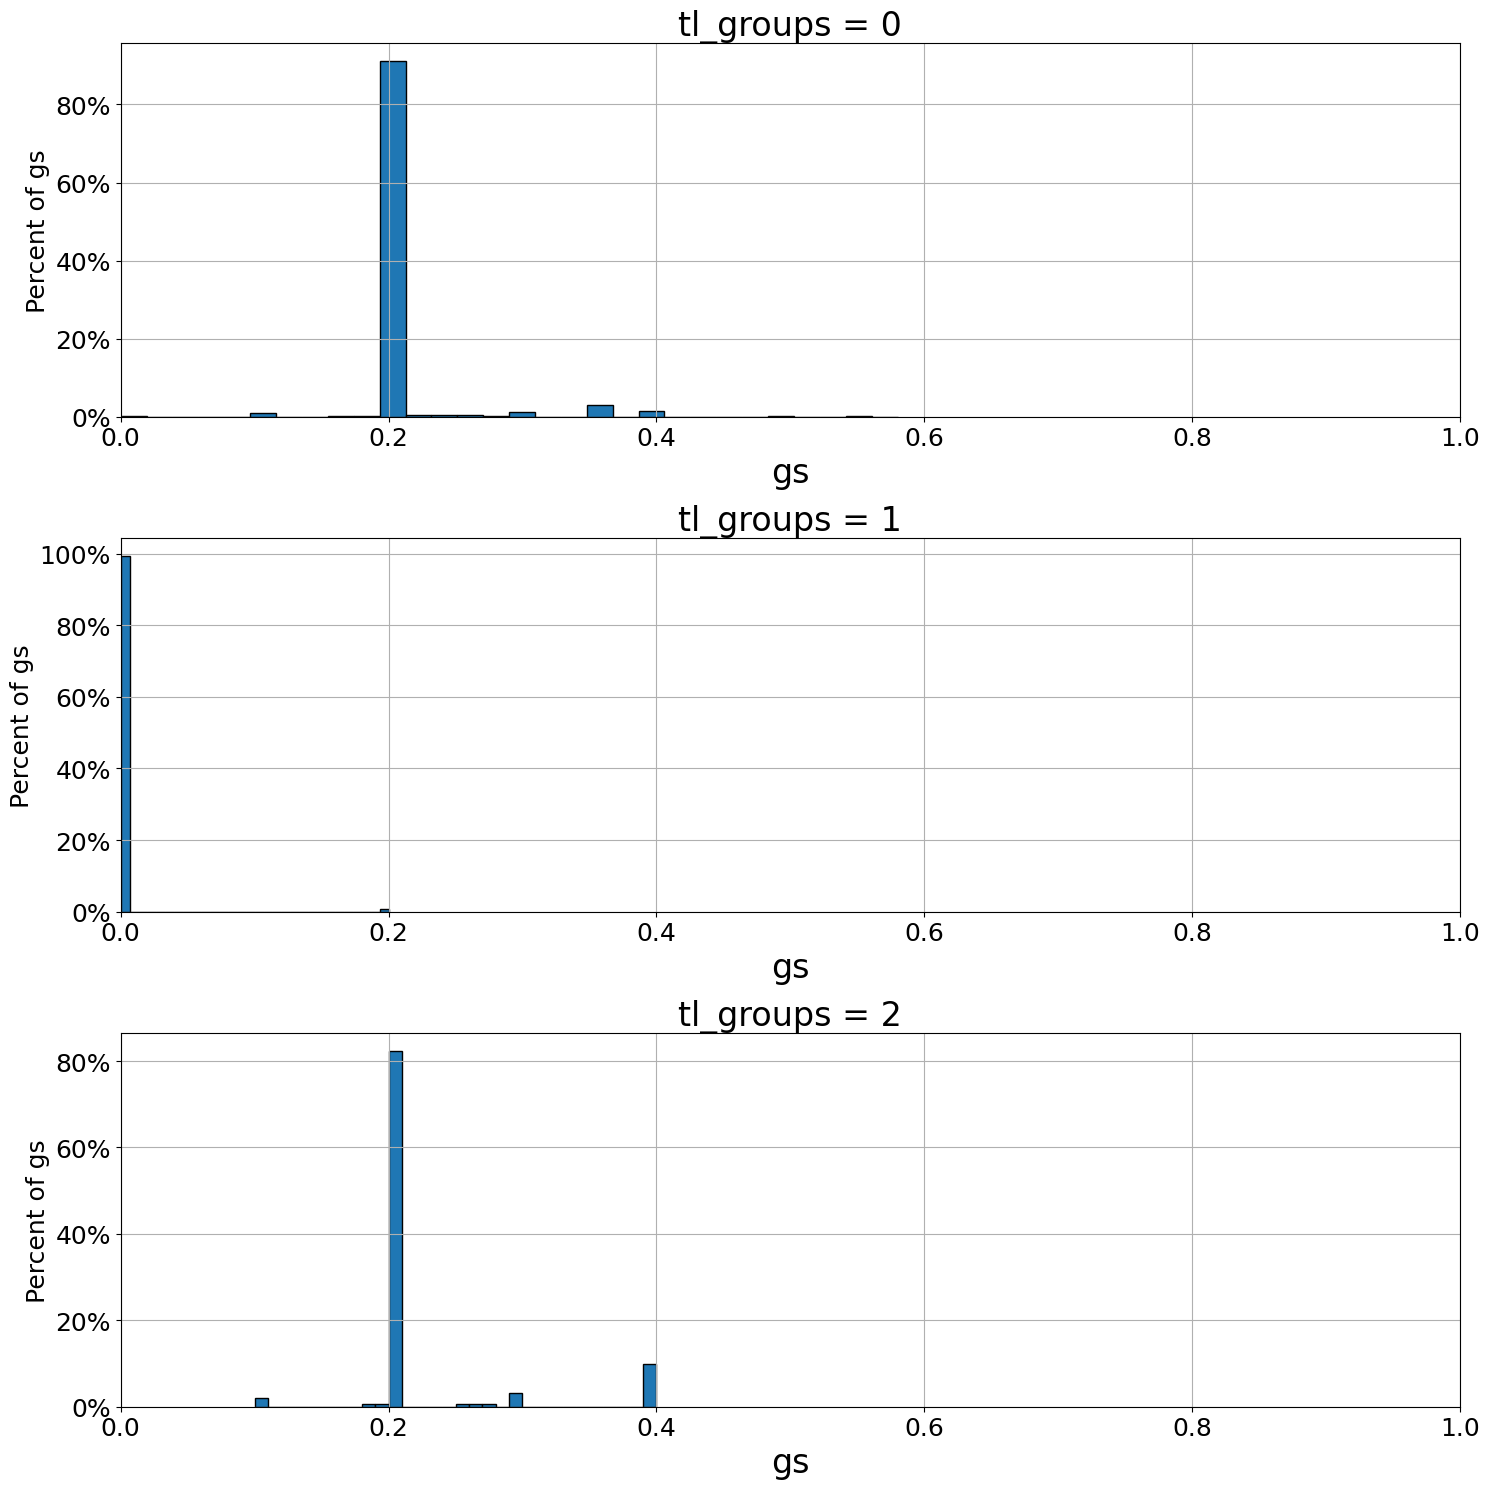

In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

fig, axes = plt.subplots(3, 1, figsize=(15, 15), sharex=False)

for i, tl_value in enumerate([0, 1, 2]):
    subset = df[df["tl_groups"] == tl_value]["gs"].dropna()
    weights = np.ones_like(subset) / len(subset)
    axes[i].hist(subset, bins=30, weights=weights, edgecolor="black")
    axes[i].set_title(f"tl_groups = {tl_value}", fontsize=24)
    axes[i].set_xlabel("gs", fontsize=24)
    axes[i].tick_params(axis="both", labelsize=18)
    axes[i].set_ylabel("Percent of gs", fontsize=18)
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    axes[i].set_xlim(0, 1)
    axes[i].grid()

fig.tight_layout()
plt.show()

In [16]:
model_numbers_non_default = df.loc[~df["gs"].isin([0, 0.2]), "model_number"].unique().tolist()

results = {
    'model_number': [],
    'is_gs_default': [],
    'SPPR_1986': [],
    'SPPR_1995': [],
    # 'SPPR_EwE': [],
    # 'SPPR_2015': [],
    'SPPR_new_TE': [],
    'SPPR_new_GE': [],
}

for model_number in tqdm(saved_models):
    # index:
    results['model_number'].append(model_number)
    results['is_gs_default'].append(model_number not in model_numbers_non_default)

    # full data:
    model = PPRCalculator(model_number)
    results['SPPR_1986'].append(model.get_PPR(model.SPPR_1986(), only_inner=True).sum(axis=1).sum())
    results['SPPR_1995'].append(model.get_PPR(model.SPPR_1995(global_TE=0.1), only_inner=True).sum(axis=1).sum())
    # results['SPPR_EwE'].append(model.get_PPR(model.SPPR_EwE(TE_option='TE', use_EE=True, silent=False)[0], only_inner=True).sum(axis=1).sum())
    # results['SPPR_2015'].append(model.get_PPR(model.SPPR_2015(only_pp_det=True)[0], only_inner=True).sum(axis=1).sum())
    results['SPPR_new_TE'].append(model.get_PPR(model.SPPR_new(TE_option='TE', DET_TE_vals=1)[0], only_inner=True).sum(axis=1).sum())
    results['SPPR_new_GE'].append(model.get_PPR(model.SPPR_new(TE_option='GE', DET_TE_vals=1)[0], only_inner=True).sum(axis=1).sum())

    # partial data:
    modeldata = ModelData(model_number)
    modeldata.groups_data[['gs', 'egestion', 'respiration', 'biomass_accum', 'emigration', 'immigration', 'net_migration', 'M0']] = np.nan
    # modeldata.groups_data[['gs', 'egestion', 'respiration', 'biomass_accum']] = np.nan
    # modeldata.groups_data[['gs', 'egestion', 'respiration']] = np.nan
    model = PPRCalculator.from_modeldata(modeldata, underdetermined=True, zero_biomass_accum=True, default_gs=True,
                                          solve_cols=['egestion', 'respiration', 'biomass_accum', 'emigration', 'immigration', 'net_migration'])
    results['SPPR_1986'][-1] = abs((results['SPPR_1986'][-1] - model.get_PPR(model.SPPR_1986(), only_inner=True).sum(axis=1).sum())) / results['SPPR_1986'][-1]
    results['SPPR_1995'][-1] = abs((results['SPPR_1995'][-1] - model.get_PPR(model.SPPR_1995(global_TE=0.1), only_inner=True).sum(axis=1).sum())) / results['SPPR_1995'][-1]
    # results['SPPR_EwE'][-1] = (results['SPPR_EwE'][-1] - model.get_PPR(model.SPPR_EwE(TE_option='TE', use_EE=True, silent=False)[0], only_inner=True).sum(axis=1).sum()) / results['SPPR_EwE'][-1]
    # results['SPPR_2015'][-1] = abs((results['SPPR_2015'][-1] - model.get_PPR(model.SPPR_2015(only_pp_det=True)[0], only_inner=True).sum(axis=1).sum())) / results['SPPR_2015'][-1]
    results['SPPR_new_TE'][-1] = abs((results['SPPR_new_TE'][-1] - model.get_PPR(model.SPPR_new(TE_option='TE', DET_TE_vals=1)[0], only_inner=True).sum(axis=1).sum())) / results['SPPR_new_TE'][-1]
    results['SPPR_new_GE'][-1] = abs((results['SPPR_new_GE'][-1] - model.get_PPR(model.SPPR_new(TE_option='GE', DET_TE_vals=1)[0], only_inner=True).sum(axis=1).sum())) / results['SPPR_new_GE'][-1]

df_results = pd.DataFrame(results)

  0%|          | 0/119 [00:00<?, ?it/s]

LIM Failed: Inequality constraints incompatible


  1%|          | 1/119 [00:02<04:20,  2.21s/it]

LIM Failed: Inequality constraints incompatible


  2%|▏         | 2/119 [00:04<04:15,  2.19s/it]

...

 98%|█████████▊| 117/119 [02:56<00:03,  1.88s/it]

LIM Failed: Inequality constraints incompatible


 99%|█████████▉| 118/119 [02:59<00:02,  2.13s/it]

LIM Failed: Inequality constraints incompatible


100%|██████████| 119/119 [03:01<00:00,  1.53s/it]


In [17]:
df_results

,model_number,is_gs_default,SPPR_1986,SPPR_1995,SPPR_new_TE,SPPR_new_GE
0,105,True,0.0,0.0,0.000000,0.000000
1,107,True,0.0,0.0,0.000000,0.000000
2,108,False,0.0,0.0,0.063741,0.467039
3,111,True,0.0,0.0,0.000000,0.000000
4,112,True,0.0,0.0,0.000000,0.000000
...,...,...,...,...,...,...
114,692,True,0.0,0.0,0.000000,0.000000
115,693,True,0.0,0.0,0.000000,0.000000
116,725,False,0.0,0.0,0.039416,0.471416
117,726,False,0.0,0.0,0.028830,1.261744


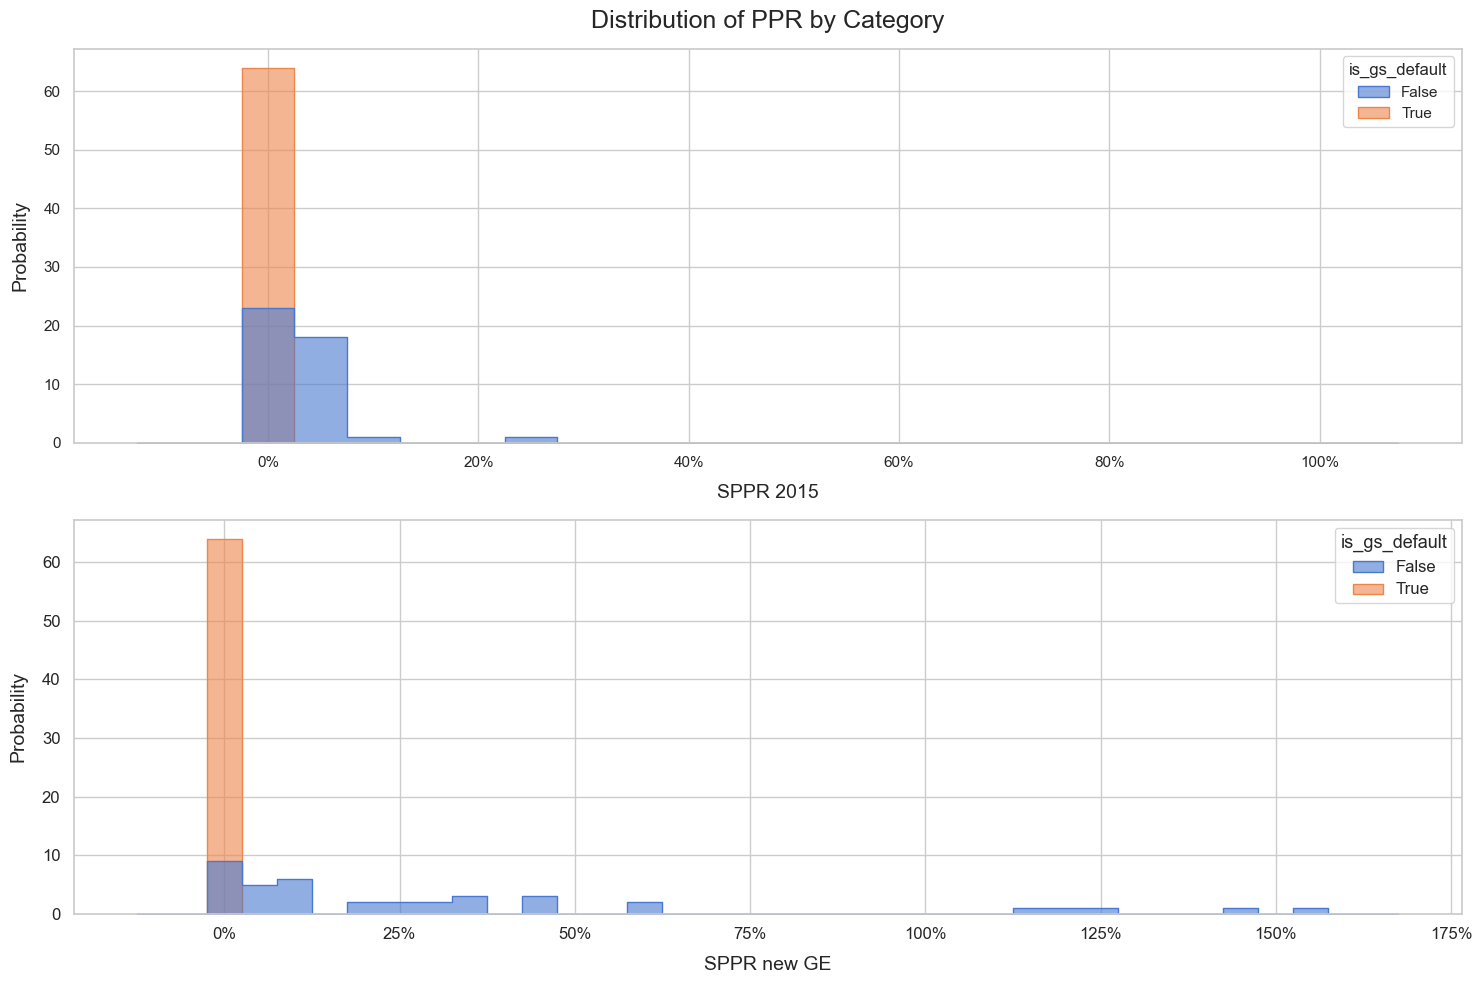

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick


df_viz = df_results.copy()
df_viz['SPPR_new_TE'] *= 100
df_viz['SPPR_new_GE'] *= 100

# Set a clean background style
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=False)

# Create the plot
ax = sns.histplot(
    data=df_viz,
    x="SPPR_new_TE",
    # bins=30,
    bins=np.arange(-12.5, 112.5, 5),
    hue="is_gs_default",
    kde=False,
    palette="muted",
    element="step",
    stat='count',
    alpha=0.6,
    ax=axes[0]
)

# Customize titles and labels with big fonts
ax.set_title("Distribution of PPR by Category", fontsize=18, pad=15)
ax.set_xlabel("SPPR 2015", fontsize=14, labelpad=10)
ax.set_ylabel("Probability", fontsize=14, labelpad=10)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
# ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

# Create the plot
ax = sns.histplot(
    data=df_viz,
    x="SPPR_new_GE",
    # bins=30,
    bins=np.arange(-12.5, 172.5, 5),
    hue="is_gs_default",
    kde=False,
    palette="muted",
    element="step",
    stat='count',
    alpha=0.6,
    ax=axes[1]
)

# Customize titles and labels with big fonts
ax.set_xlabel("SPPR new GE", fontsize=14, labelpad=10)
ax.set_ylabel("Probability", fontsize=14, labelpad=10)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
# ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

# Make axis tick marks larger
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Make the legend text larger
plt.setp(ax.get_legend().get_texts(), fontsize="12")
plt.setp(ax.get_legend().get_title(), fontsize="13")

# Adjust spacing and display
plt.tight_layout()
plt.show()